In [ ]:
print("Kernel Connected 🚀")

In [ ]:
import pandas as pd

df = pd.read_csv("30_Auto_theft.csv")

df.head()

In [ ]:
df.columns

In [ ]:
df = pd.read_csv("Project/30_Auto_theft.csv")

In [1]:
print("Working")

Working


In [2]:
import pandas as pd

df = pd.read_csv("Project/30_Auto_theft.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Project/30_Auto_theft.csv'

In [3]:
import os
os.getcwd()

'e:\\8 SEM PROJECT\\Project'

In [4]:
import pandas as pd

df = pd.read_csv("30_Auto_theft.csv")

df.head()

,Area_Name,Year,Group_Name,Sub_Group_Name,Auto_Theft_Coordinated/Traced,Auto_Theft_Recovered,Auto_Theft_Stolen
0,Andaman & Nicobar Islands,2001,AT1-Motor Cycles/ Scooters,1. Motor Cycles/ Scooters,NaN,4.0,4
1,Andhra Pradesh,2001,AT1-Motor Cycles/ Scooters,1. Motor Cycles/ Scooters,136.0,1311.0,2725
2,Arunachal Pradesh,2001,AT1-Motor Cycles/ Scooters,1. Motor Cycles/ Scooters,0.0,21.0,27
3,Assam,2001,AT1-Motor Cycles/ Scooters,1. Motor Cycles/ Scooters,0.0,94.0,205
4,Bihar,2001,AT1-Motor Cycles/ Scooters,1. Motor Cycles/ Scooters,44.0,205.0,946


In [5]:
df.columns

Index(['Area_Name', 'Year', 'Group_Name', 'Sub_Group_Name',
       'Auto_Theft_Coordinated/Traced', 'Auto_Theft_Recovered',
       'Auto_Theft_Stolen'],
      dtype='str')

In [6]:
df = df[['Area_Name', 'Year', 'Auto_Theft_Stolen']]

df.head()

,Area_Name,Year,Auto_Theft_Stolen
0,Andaman & Nicobar Islands,2001,4
1,Andhra Pradesh,2001,2725
2,Arunachal Pradesh,2001,27
3,Assam,2001,205
4,Bihar,2001,946


In [7]:
df = df.rename(columns={
    'Area_Name': 'Border_Zone',
    'Auto_Theft_Stolen': 'Incident_Count'
})

df.head()

,Border_Zone,Year,Incident_Count
0,Andaman & Nicobar Islands,2001,4
1,Andhra Pradesh,2001,2725
2,Arunachal Pradesh,2001,27
3,Assam,2001,205
4,Bihar,2001,946


In [8]:
zone_data = df.groupby('Border_Zone')['Incident_Count'].sum().reset_index()

zone_data.head()

,Border_Zone,Incident_Count
0,Andaman & Nicobar Islands,166
1,Andhra Pradesh,113618
2,Arunachal Pradesh,1658
3,Assam,22236
4,Bihar,45754


In [9]:
# Check distribution first
zone_data['Incident_Count'].describe()

count        35.00000
mean      54854.00000
std       71219.45212
min          22.00000
25%        2868.00000
50%       22236.00000
75%       97962.00000
max      262564.00000
Name: Incident_Count, dtype: float64

In [10]:
def classify_risk(count):
    if count <= 22236:
        return "Low"
    elif count <= 97962:
        return "Medium"
    else:
        return "High"

zone_data['Risk_Level'] = zone_data['Incident_Count'].apply(classify_risk)

zone_data.head()

,Border_Zone,Incident_Count,Risk_Level
0,Andaman & Nicobar Islands,166,Low
1,Andhra Pradesh,113618,High
2,Arunachal Pradesh,1658,Low
3,Assam,22236,Low
4,Bihar,45754,Medium


In [11]:
zone_data['Risk_Level'].value_counts()

Risk_Level
Low       18
High       9
Medium     8
Name: count, dtype: int64

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
zone_data['Risk_Label'] = le.fit_transform(zone_data['Risk_Level'])

zone_data.head()

,Border_Zone,Incident_Count,Risk_Level,Risk_Label
0,Andaman & Nicobar Islands,166,Low,1
1,Andhra Pradesh,113618,High,0
2,Arunachal Pradesh,1658,Low,1
3,Assam,22236,Low,1
4,Bihar,45754,Medium,2


In [14]:
X = zone_data[['Incident_Count']]
y = zone_data['Risk_Label']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [17]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.8571428571428571

In [18]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[1 0 0]
 [0 5 0]
 [0 1 0]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.83      1.00      0.91         5
           2       0.00      0.00      0.00         1

    accuracy                           0.86         7
   macro avg       0.61      0.67      0.64         7
weighted avg       0.74      0.86      0.79         7



c:\Users\jacobnayak18\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jacobnayak18\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jacobnayak18\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

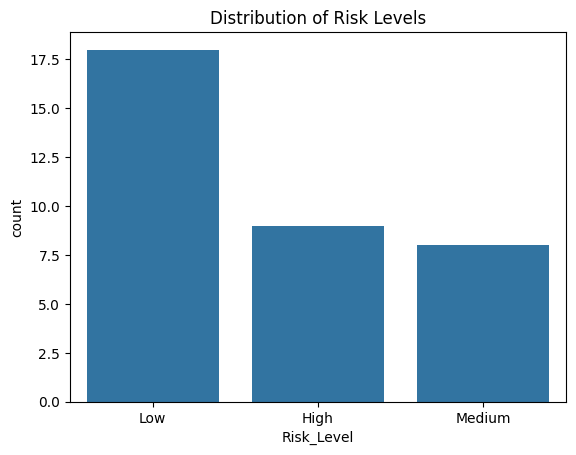

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(data=zone_data, x='Risk_Level')
plt.title("Distribution of Risk Levels")
plt.show()

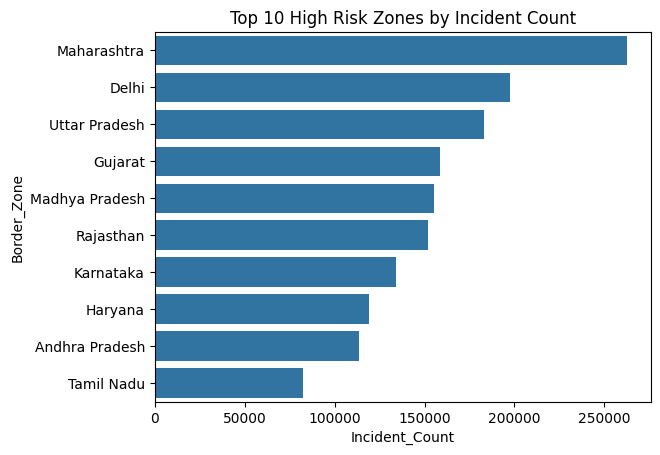

In [20]:
top10 = zone_data.sort_values(by='Incident_Count', ascending=False).head(10)

plt.figure()
sns.barplot(data=top10, x='Incident_Count', y='Border_Zone')
plt.title("Top 10 High Risk Zones by Incident Count")
plt.show()

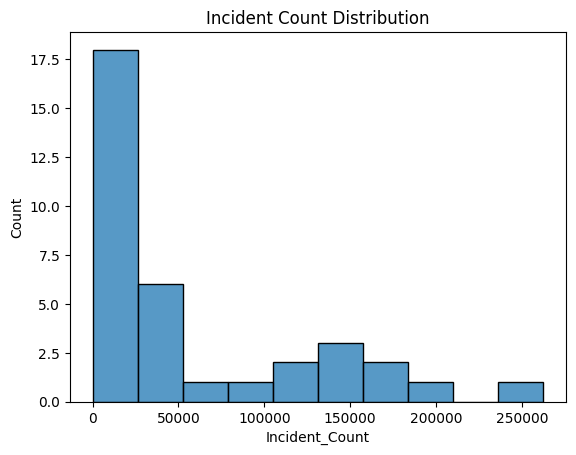

In [21]:
plt.figure()
sns.histplot(zone_data['Incident_Count'], bins=10)
plt.title("Incident Count Distribution")
plt.show()

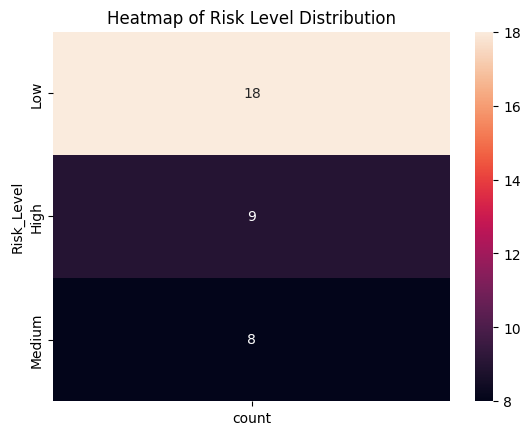

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
risk_counts = zone_data['Risk_Level'].value_counts().to_frame()
sns.heatmap(risk_counts, annot=True, fmt='d')
plt.title("Heatmap of Risk Level Distribution")
plt.show()

In [23]:
zone_data.to_csv("final_border_risk_dataset.csv", index=False)